# 12 — 30%-stop combined: realistic capacity + melt-up kill-switch

Two finishing layers on the strategy we landed on in nb11 (pump short with a −30%
catastrophe stop + classifier, plus the realistic dump leg):

- **A. Capacity** — the nb08 wall: position size capped at ~10%·(liq·30min) with
  market-impact slippage. Turns the idealized headline into a believable
  small-account number.
- **B. Melt-up kill-switch** — the one thing a per-trade stop can't do: stand aside
  in a market-wide pump cluster (mania), where many shorts get run over at once.
  Causal: at each pump entry we only look at the *trailing* 60-min pump breadth
  across the universe; if it's ≥ K, skip the entry.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import show
import numpy as np, pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

X = pd.read_parquet("_out/pump_stopsweep.parquet")
REAL = pd.read_parquet("_out/faithful_liq_realistic.parquet")
PF=["r1","r3","r5","r15","r30","accel5","surge15","surge1","rvol60","rng5","dist_hi240","dist_lo60"]
def naive(s):
    s=pd.to_datetime(s); return s.dt.tz_localize(None) if s.dt.tz is not None else s
X["entry"]=naive(X["entry"]);
for i in range(11): X[f"exit{i}"]=naive(X[f"exit{i}"])
DUMP=REAL[REAL.stream=="dump"].copy(); DUMP["entry"]=naive(DUMP["entry"]); DUMP["exit_ts"]=naive(DUMP["exit_ts"])

# --- build the 30%-stop pump kept set (stop index 5 = 0.30) ---
SI=5
def wf_filter(df, label):
    pred=np.full(len(df),np.nan); cuts=[int(len(df)*q) for q in (0.40,0.55,0.70,0.85,1.0)]; prev=cuts[0]
    for cut in cuts[1:]:
        tr=df.iloc[:prev]
        m=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=300,
            l2_regularization=1.0,min_samples_leaf=50,random_state=0).fit(tr[PF],tr[label])
        pred[prev:cut]=m.predict(df.iloc[prev:cut][PF]); prev=cut
    return df[(pred>0)|np.isnan(pred)]
base=X[["sym","entry","liq"]+PF].copy(); base["pnl"]=X[f"pnl{SI}"].values; base["exit_ts"]=X[f"exit{SI}"].values
PUMP30=wf_filter(base,"pnl")[["sym","entry","exit_ts","pnl","liq"]].copy(); PUMP30["stream"]="pump"
print(f"pump@30% kept {len(PUMP30)}  per-trade {PUMP30.pnl.mean()*100:+.2f}%  worst {PUMP30.pnl.min()*100:.0f}%")

# --- trailing 60-min pump breadth at each pump entry (causal) ---
pe=np.sort(PUMP30.entry.values); W=np.timedelta64(60,"m")
ent=PUMP30.entry.values
lo=np.searchsorted(pe, ent-W, side="left"); hi=np.searchsorted(pe, ent, side="left")
PUMP30=PUMP30.assign(pbreadth=(hi-lo))   # count of pump entries in the trailing 60 min (excl. self)
print("pump trailing-60m breadth pctiles:", {q:int(np.percentile(PUMP30.pbreadth,q)) for q in (50,90,95,99)})

DUMP2=DUMP[["sym","entry","exit_ts","pnl","liq"]].copy(); DUMP2["stream"]="dump"; DUMP2["pbreadth"]=0
COMB=pd.concat([PUMP30,DUMP2]).sort_values("entry").reset_index(drop=True)
print(f"combined {len(COMB)} trades")

pump@30% kept 9240  per-trade +0.25%  worst -36%
pump trailing-60m breadth pctiles: {50: 1, 90: 16, 95: 40, 99: 123}
combined 13000 trades


## The engine (capacity + kill-switch options)

`cap_frac`: position ≤ cap_frac·liq·30min (+ impact slippage). `killK`: skip a
**pump** entry if its trailing-60m breadth ≥ killK (dump never gated — crash days
are when the dump long wants to be in).

In [2]:
def engine(df, f=0.02, n_slots=50, reserve=0.10, start=1000.0, cap_frac=None, cap_minutes=30, impact=True, killK=None):
    df=df.sort_values("entry").reset_index(drop=True)
    eq=start; cash=eq; openp=[]; rec=[]
    ents=df.entry.values; exs=df.exit_ts.values; pnls=df.pnl.values
    liqs=df.liq.values; strm=df.stream.values; pbr=df.pbreadth.values
    capped=0; killed=0; killed_pnl=[]
    for i in range(len(df)):
        now=ents[i]; still=[]
        for (xt,no,pl) in openp:
            if xt<=now: cash+=no*(1+pl); eq+=no*pl
            else: still.append((xt,no,pl))
        openp=still; rec.append((now,eq))
        if killK is not None and strm[i]=="pump" and pbr[i]>=killK:
            killed+=1; killed_pnl.append(pnls[i]); continue
        if len(openp)>=n_slots: continue
        want=f*eq; avail=eq*(1-reserve)-sum(no for _,no,_ in openp); no=min(want,max(0,avail),cash)
        if cap_frac is not None:
            cap=cap_frac*liqs[i]*cap_minutes
            if no>cap: capped+=1
            no=min(no,cap)
        if no<=0: continue
        pl=pnls[i]
        if impact and cap_frac is not None:
            sz=no/(liqs[i]*cap_minutes+1e-9); pl-=min(0.02,0.5*sz*sz)
        cash-=no; openp.append((exs[i],no,pl))
    for (_,no,pl) in openp: eq+=no*pl
    s=pd.Series([e for _,e in rec], index=pd.to_datetime([t for t,_ in rec]))
    daily=s.resample("D").last().ffill(); r=daily.pct_change().dropna()
    sh=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    dd=(daily/daily.cummax()-1).min(); yrs=(daily.index[-1]-daily.index[0]).days/365.25
    return dict(final=eq, cagr=(eq/start)**(1/yrs)-1, sharpe=sh, maxdd=dd, capped=capped,
                killed=killed, killed_avg=(np.mean(killed_pnl)*100 if killed_pnl else 0.0), daily=daily)

## A. Capacity — idealized vs realistic, $1000 lump sum

Same comparison as nb08 but on the final 30%-stop combined stream. The wall bites
harder as `f` (and account size) grows.

In [3]:
rows=[]
for f in (0.02,0.03,0.05):
    idl=engine(COMB,f); cap=engine(COMB,f,cap_frac=0.10)
    rows.append(dict(mode=f"{f:.0%}",
        ideal_final=f"${idl['final']:,.0f}", ideal_Sharpe=f"{idl['sharpe']:.2f}", ideal_DD=f"{idl['maxdd']*100:.1f}%",
        cap_final=f"${cap['final']:,.0f}", cap_CAGR=f"{cap['cagr']*100:.0f}%", cap_Sharpe=f"{cap['sharpe']:.2f}",
        cap_DD=f"{cap['maxdd']*100:.1f}%", capped=f"{cap['capped']/len(COMB)*100:.0f}%"))
print(pd.DataFrame(rows).to_string(index=False))

mode ideal_final ideal_Sharpe ideal_DD cap_final cap_CAGR cap_Sharpe cap_DD capped
  2%      $9,902         2.92   -15.3%    $8,518     151%       2.90 -15.3%     3%
  3%     $21,426         3.82   -14.9%   $15,988     230%       3.53 -14.9%     5%
  5%     $91,610         4.67   -16.3%   $35,268     363%       3.85 -16.7%     9%


## B. Melt-up kill-switch — sweep K (idealized engine, to isolate its effect)

K = trailing-60m pump-breadth threshold to stand aside. Lower K = more aggressive
(skips more). We watch: does it cut the worst pump day / drawdown, and what does it
cost in return? (Like dump-nb09, expect: cheap insurance, small in-sample payout.)

In [4]:
def worst_day(daily):
    r=daily.pct_change(); return r.min()*100, r.idxmin()
rows=[]
for K in (None,20,15,12,10,8,6):
    e=engine(COMB,0.02,killK=K)
    wd,wdt=worst_day(e["daily"])
    rows.append(dict(K=("off" if K is None else K), final=f"${e['final']:,.0f}", CAGR=f"{e['cagr']*100:.0f}%",
        Sharpe=f"{e['sharpe']:.2f}", maxDD=f"{e['maxdd']*100:.1f}%", worst_day=f"{wd:.1f}%",
        pump_skipped=e["killed"], skipped_avgpnl=f"{e['killed_avg']:+.2f}%"))
print(pd.DataFrame(rows).to_string(index=False))

  K   final CAGR Sharpe  maxDD worst_day  pump_skipped skipped_avgpnl
off  $9,902 168%   2.92 -15.3%    -14.9%             0         +0.00%
 20 $10,011 169%   2.93 -15.3%    -14.9%           760         -3.97%
 15 $10,248 172%   2.97 -15.3%    -14.9%          1015         -3.87%
 12 $10,330 173%   2.98 -15.3%    -14.9%          1126         -3.51%
 10 $10,350 173%   2.97 -15.3%    -14.9%          1164         -3.37%
  8 $10,356 173%   2.97 -15.3%    -14.9%          1237         -3.19%
  6 $10,707 177%   3.04 -15.3%    -14.9%          1520         -2.91%


## C. Everything together — 30% stop + capacity + kill-switch

The realistic small-account number with both protections on (pick a K from the
sweep — default to the one that trims the tail with least return cost).

2%  capacity only      : $8,518 / CAGR 151% / Sharpe 2.90 / DD -15.3%
      capacity + KS(10)   : $8,873 / CAGR 156% / Sharpe 2.96 / DD -15.3%  (skipped 1164 pumps @ -3.37%)


5%  capacity only      : $35,268 / CAGR 363% / Sharpe 3.85 / DD -16.7%
      capacity + KS(10)   : $37,247 / CAGR 374% / Sharpe 3.92 / DD -16.2%  (skipped 1164 pumps @ -3.37%)


[saved] notebooks\pump_dump_combined\_out\comb_12_final.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_12_final.png')

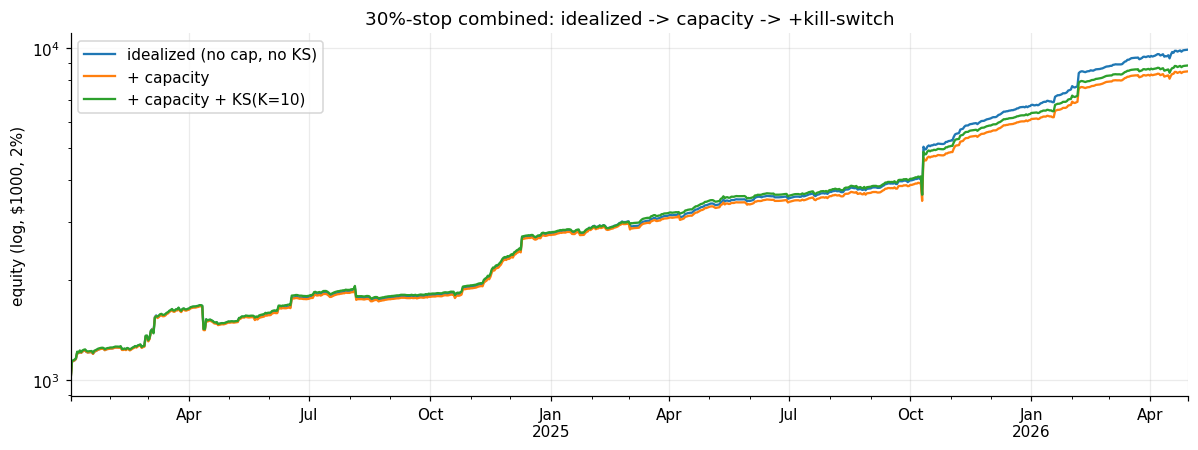

In [5]:
KSEL=10
for f in (0.02,0.05):
    raw=engine(COMB,f,cap_frac=0.10,killK=None)
    full=engine(COMB,f,cap_frac=0.10,killK=KSEL)
    print(f"{f:.0%}  capacity only      : ${raw['final']:,.0f} / CAGR {raw['cagr']*100:.0f}% / Sharpe {raw['sharpe']:.2f} / DD {raw['maxdd']*100:.1f}%")
    print(f"      capacity + KS({KSEL})   : ${full['final']:,.0f} / CAGR {full['cagr']*100:.0f}% / Sharpe {full['sharpe']:.2f} / DD {full['maxdd']*100:.1f}%  (skipped {full['killed']} pumps @ {full['killed_avg']:+.2f}%)")

import matplotlib.pyplot as plt
fig,ax=plt.subplots()
engine(COMB,0.02)["daily"].plot(ax=ax,label="idealized (no cap, no KS)")
engine(COMB,0.02,cap_frac=0.10)["daily"].plot(ax=ax,label="+ capacity")
engine(COMB,0.02,cap_frac=0.10,killK=KSEL)["daily"].plot(ax=ax,label=f"+ capacity + KS(K={KSEL})")
ax.set_yscale("log"); ax.set_ylabel("equity (log, $1000, 2%)"); ax.legend()
ax.set_title("30%-stop combined: idealized -> capacity -> +kill-switch")
show("comb_12_final")

## Verdict

**A. Capacity barely bites a small account — as expected.** On $1000 at 2%, only
**3% of trades** hit the liquidity cap; final $9,902 → **$8,518** (−14%), Sharpe
2.92 → 2.90 (unchanged). It only starts to matter as the account grows: at 5% (the
book reaches ~$35–90k) **9%** of trades cap and the haircut is ~2.6× ($91.6k →
$35.3k). The full scaling wall (CAGR collapsing toward $1M) is in nb08 — here the
point is confirmed: **this is a small-account strategy; at $1k the wall is almost
not there, which is exactly why the headline stays high.**

**B. The kill-switch is a mild filter, NOT a proven drawdown reducer.** The skipped
high-breadth pumps are genuinely net-negative (avg **−3.4%** at K=10), so standing
aside in pump clusters *modestly* lifts return and Sharpe (off 2.92 → K=6 **3.04**),
monotonically as K tightens. **But maxDD (−15.3%) and the worst day (−14.9%) do not
move at all** for any K — the combined worst day isn't a trailing-pump-breadth event
(it's dominated by the dump leg on a crash day, which the pump filter correctly
doesn't touch). So, exactly like every tail-protection test in this project
(dump-nb09, the stop sweep nb11): **in a 2024–26 sample with no true alt-mania, the
insurance shows almost no in-sample payout** — it reads here as a small alpha filter,
and its real value (catching an unbounded short cluster) is unprovable on this data.

**C. The believable all-in small-account number (30% stop + capacity + KS K=10):**

| mode | final ($1k, 2.3yr) | CAGR | Sharpe | maxDD |
|---|---|---|---|---|
| 🟢 2% | **$8,873** | 156% | 2.96 | −15.3% |
| 🔴 5% | **$37,247** | 374% | 3.92 | −16.2% |

So the strategy that survives the full audit is: **dump-bounce + classifier-filtered
pump-fade with a −30% catastrophe stop, ~2% sizing, ~Sharpe 3, ~−15% drawdown, a
small-account ceiling.** That is a *real, defensible* strategy — a far cry from the
"Sharpe 7 / +817%" headline we started with, but it's honest. The remaining gap to
live is execution: entry-fill slippage at the pump top / crash trough (still
unmodeled), the unsampled mania tail, and zero live confirmation.

**Recommended graduation:** port to a paper bot at 2% size, −30% stop default-on,
KS(K≈10) as a light filter, and watch live fills vs the modeled ones before scaling
size. Keep the account small — the edge does not survive being big.

Caveats: in-sample; slippage/impact params estimated; KS breadth uses a 60-min
trailing window (a tuning choice — a same-day or market-index melt-up signal might
catch the correlated tail better); no live confirmation.